#### Training Model

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# 1) Load data
# df = pd.read_csv("data/dummy_java_ash_predictor_10rows.csv")
df = pd.read_csv("data/data_ash_dummy.csv")

# 2) Pisahkan fitur (X) dan target (y)
X = df[["Tinggi_Letusan_m", "Kec_Angin_km_jam", "Arah_Angin_deg"]]
y = df[["Jarak_km", "Luas_km2", "Sudut_deg", "Radius_km"]]

In [4]:
# 3) Split train-test
# Dengan data dummy yang sangat kecil, ini hanya untuk demo alur (bukan evaluasi serius)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# 4) Base regressor (XGBoost)
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    verbosity=1  # 0=silent, 1=warning, 2=info, 3=debug
)

# 5) Bungkus jadi multi-output
model = MultiOutputRegressor(xgb_base, n_jobs=-1)  # 1 regressor per target [web:2]
model.fit(X_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,n_jobs,-1
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None


In [6]:
# 6) Prediksi
y_pred = model.predict(X_test)  # shape: (n_samples, 4) [web:2]

In [7]:
# 7) Evaluasi sederhana per-target
target_names = y.columns.tolist()
y_test_np = y_test.to_numpy()

for i, name in enumerate(target_names):
    mae = mean_absolute_error(y_test_np[:, i], y_pred[:, i])
    mse = mean_squared_error(y_test_np[:, i], y_pred[:, i])
    print(f"{name}: MAE={mae:.3f}, MSE={mse:.3f}")

Jarak_km: MAE=3.525, MSE=20.742
Luas_km2: MAE=33.077, MSE=1774.011
Sudut_deg: MAE=4.501, MSE=32.661
Radius_km: MAE=1.332, MSE=2.803


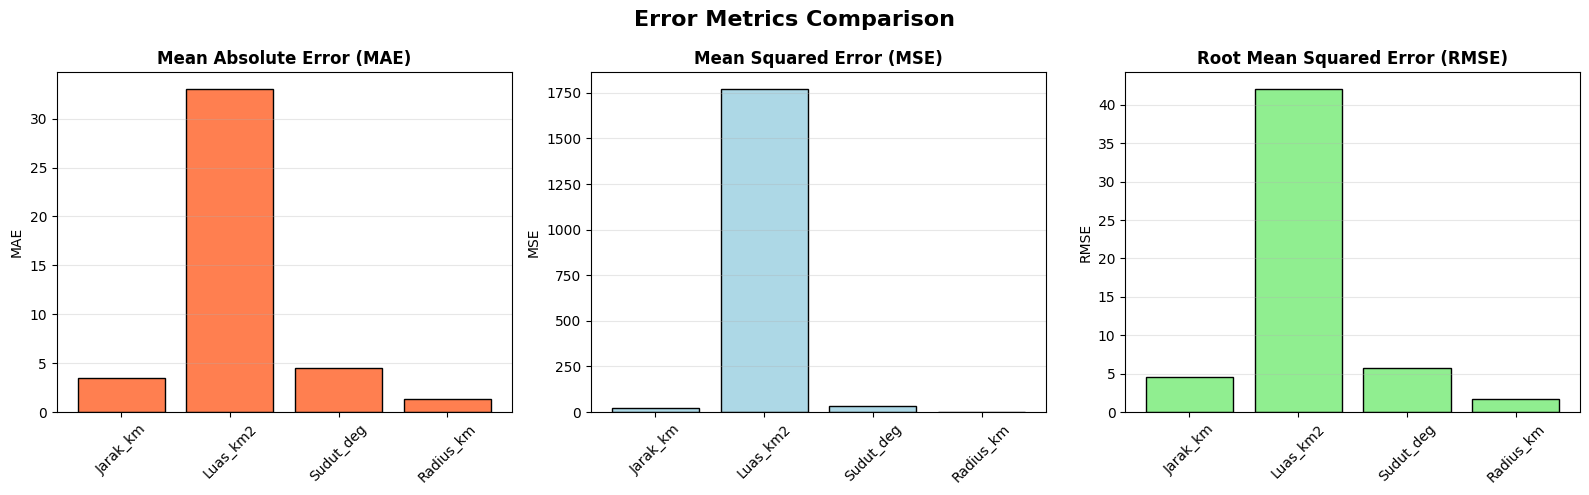


📊 Ringkasan Error Metrics:
   Target       MAE         MSE      RMSE
 Jarak_km  3.525200   20.741783  4.554315
 Luas_km2 33.077312 1774.010849 42.119008
Sudut_deg  4.501275   32.661463  5.715021
Radius_km  1.332201    2.802552  1.674082


In [8]:
# Plot 4: Error Metrics Summary
metrics_data = []
for i, name in enumerate(target_names):
    mae = mean_absolute_error(y_test_np[:, i], y_pred[:, i])
    mse = mean_squared_error(y_test_np[:, i], y_pred[:, i])
    rmse = np.sqrt(mse)
    metrics_data.append({'Target': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse})

metrics_df = pd.DataFrame(metrics_data)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Error Metrics Comparison', fontsize=16, fontweight='bold')

# MAE
axes[0].bar(metrics_df['Target'], metrics_df['MAE'], color='coral', edgecolor='black')
axes[0].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# MSE
axes[1].bar(metrics_df['Target'], metrics_df['MSE'], color='lightblue', edgecolor='black')
axes[1].set_title('Mean Squared Error (MSE)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MSE')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

# RMSE
axes[2].bar(metrics_df['Target'], metrics_df['RMSE'], color='lightgreen', edgecolor='black')
axes[2].set_title('Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('RMSE')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Tampilkan tabel metrics
print("\n📊 Ringkasan Error Metrics:")
print(metrics_df.to_string(index=False))

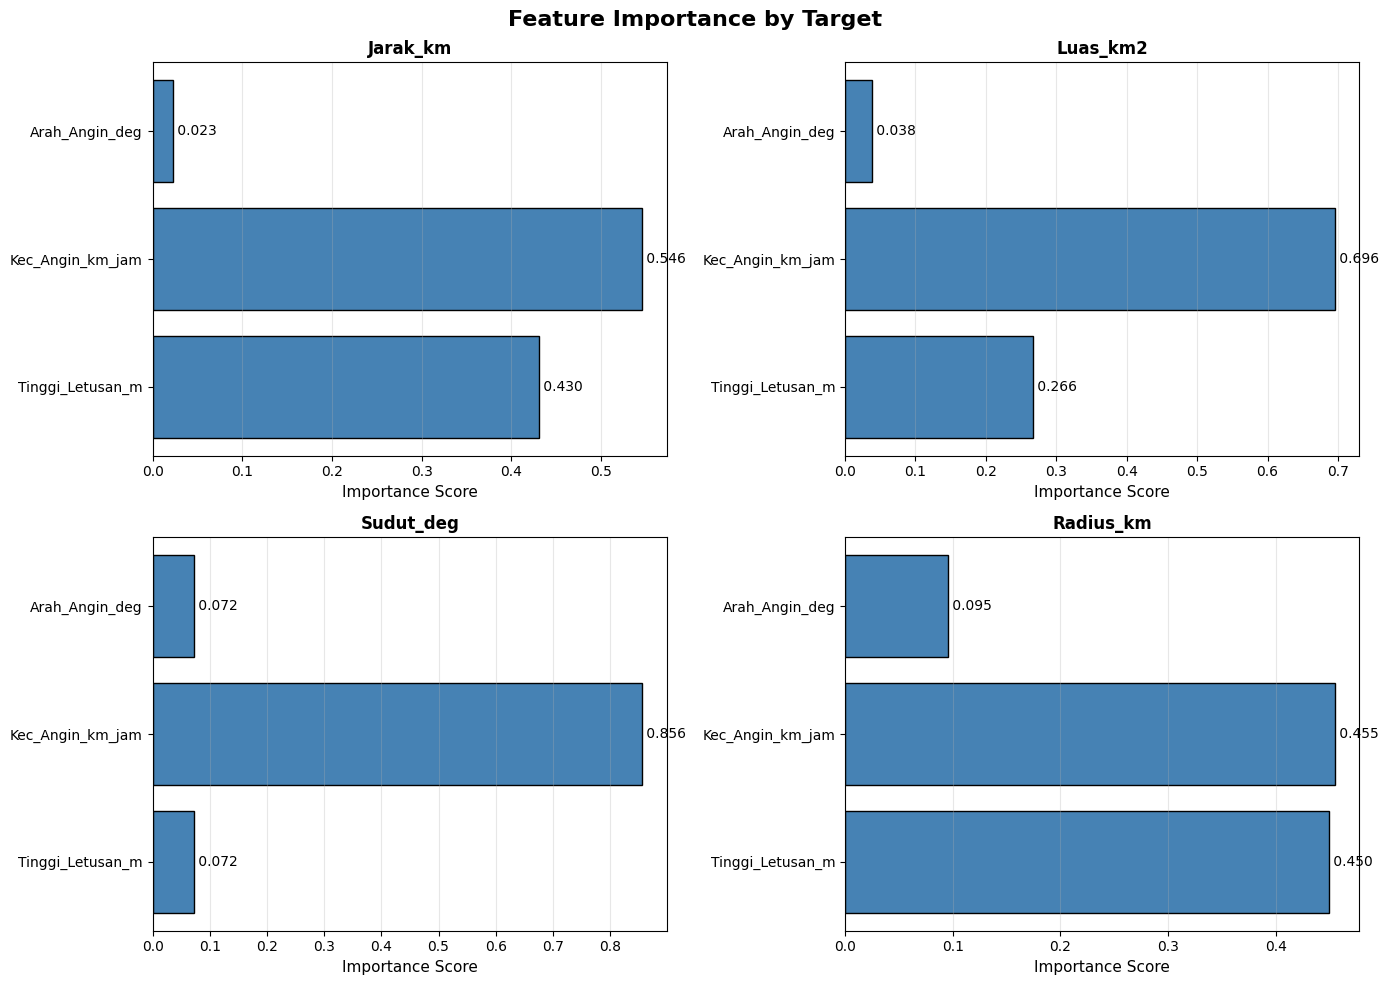

In [9]:
# Plot 3: Feature Importance untuk setiap target
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Importance by Target', fontsize=16, fontweight='bold')

feature_names = X.columns.tolist()

for i, (ax, name) in enumerate(zip(axes.flatten(), target_names)):
    # Dapatkan feature importance dari model untuk target ke-i
    importance = model.estimators_[i].feature_importances_
    
    # Buat bar plot
    bars = ax.barh(feature_names, importance, color='steelblue', edgecolor='black')
    
    # Tambahkan nilai di setiap bar
    for j, (bar, val) in enumerate(zip(bars, importance)):
        ax.text(val, j, f' {val:.3f}', va='center', fontsize=10)
    
    # Labels and formatting
    ax.set_xlabel('Importance Score', fontsize=11)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

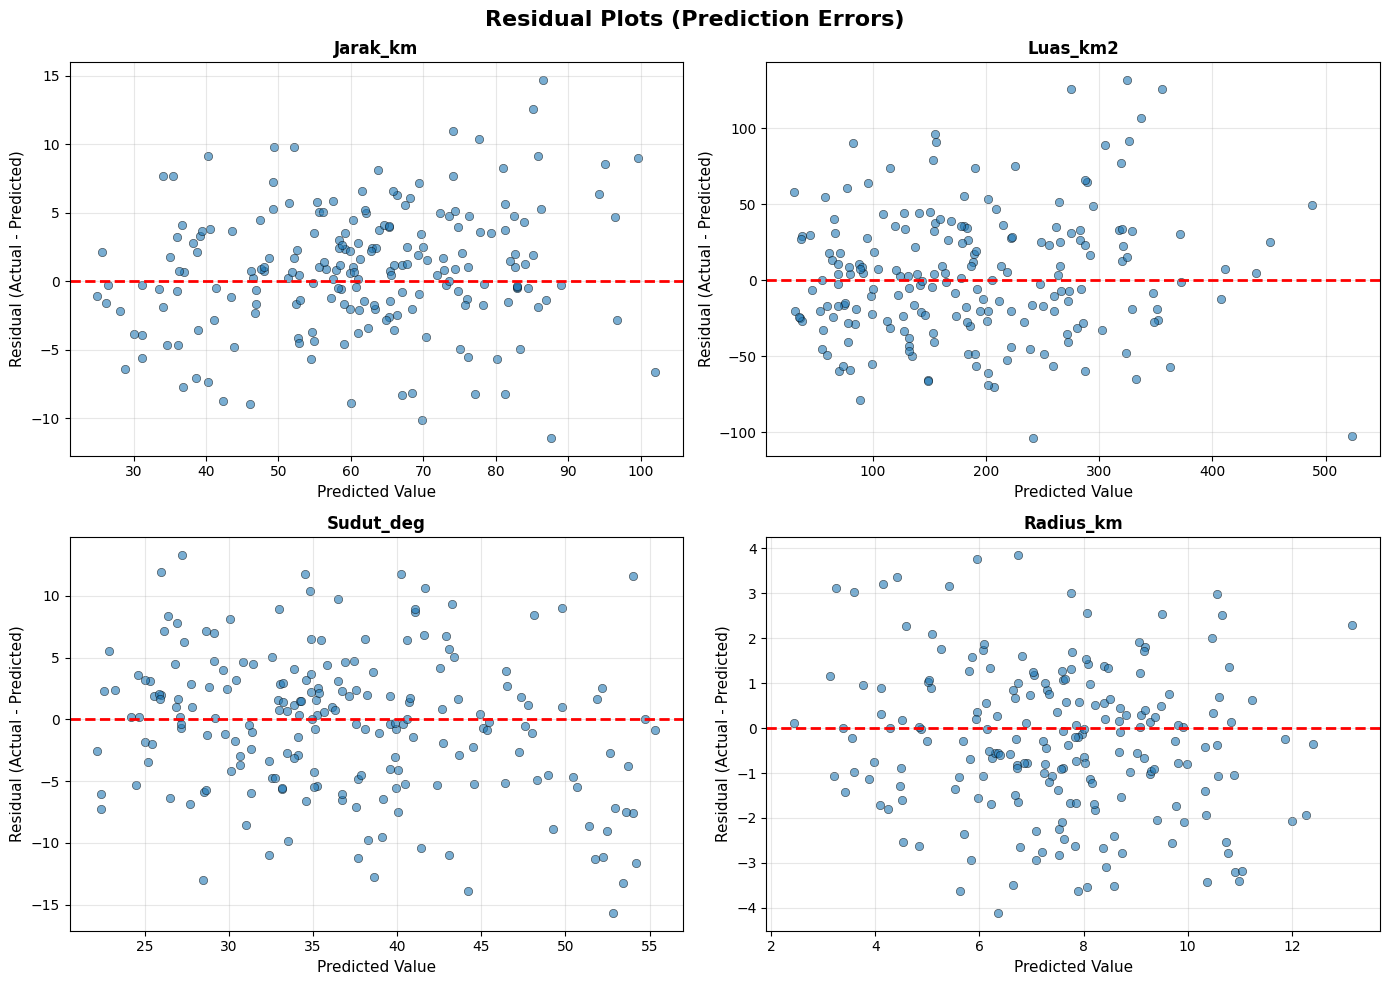

In [10]:
# Plot 2: Residual Plots (Error Distribution)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Residual Plots (Prediction Errors)', fontsize=16, fontweight='bold')

for i, (ax, name) in enumerate(zip(axes.flatten(), target_names)):
    residuals = y_test_np[:, i] - y_pred[:, i]
    
    # Residual scatter plot
    ax.scatter(y_pred[:, i], residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax.axhline(y=0, color='r', linestyle='--', lw=2)
    
    # Labels and formatting
    ax.set_xlabel('Predicted Value', fontsize=11)
    ax.set_ylabel('Residual (Actual - Predicted)', fontsize=11)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

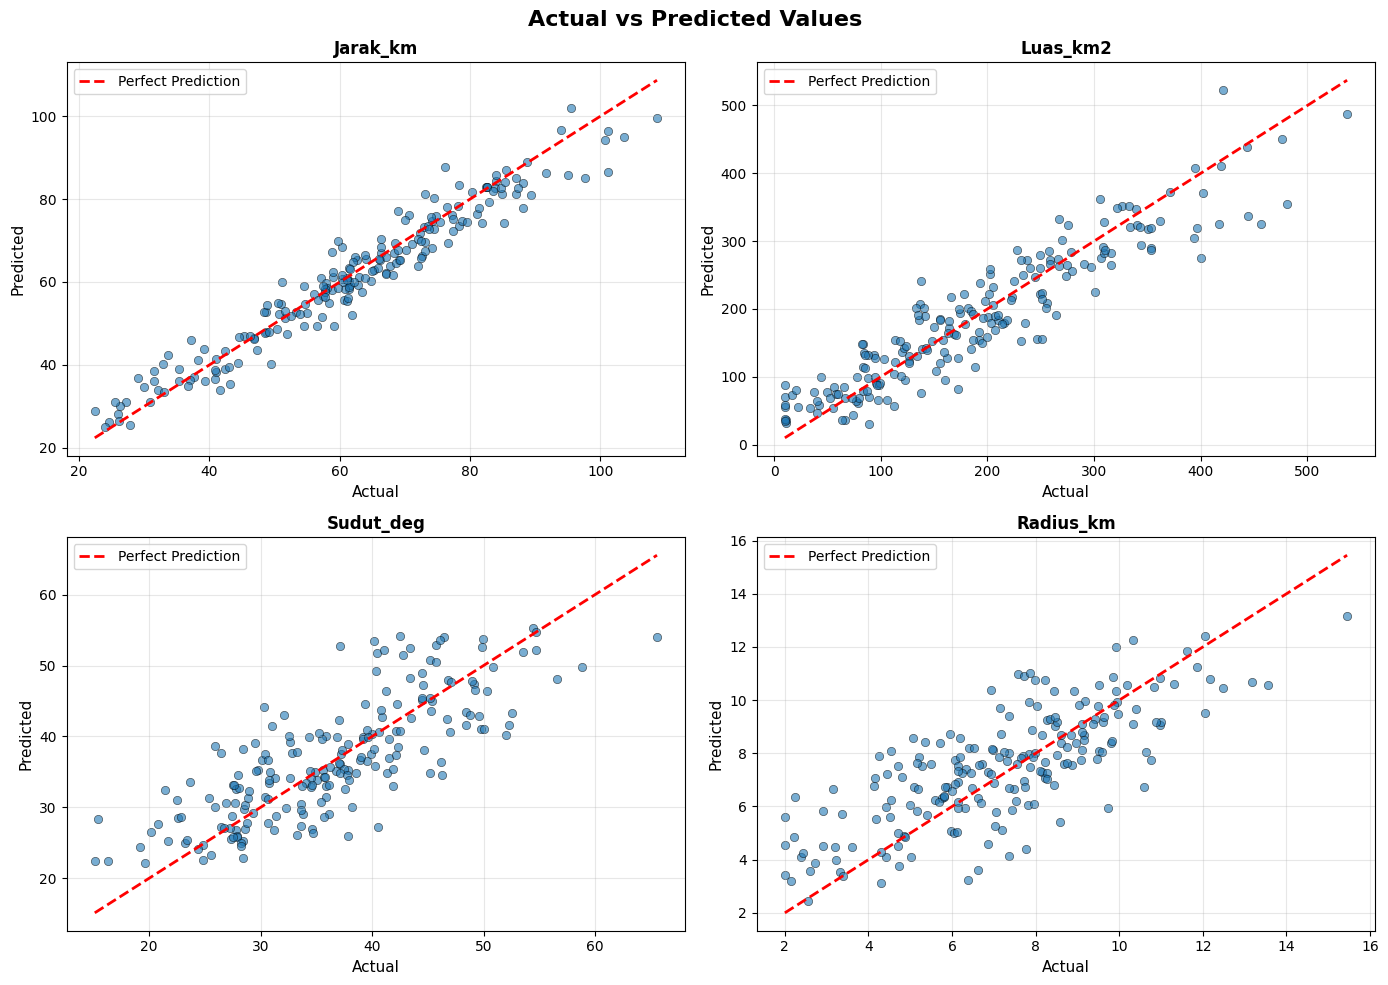

In [11]:
# 7b) Visualisasi Hasil Training

# Plot 1: Actual vs Predicted untuk setiap target
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Actual vs Predicted Values', fontsize=16, fontweight='bold')

for i, (ax, name) in enumerate(zip(axes.flatten(), target_names)):
    y_actual = y_test_np[:, i]
    y_predicted = y_pred[:, i]
    
    # Scatter plot
    ax.scatter(y_actual, y_predicted, alpha=0.6, edgecolors='k', linewidth=0.5)
    
    # Perfect prediction line
    min_val = min(y_actual.min(), y_predicted.min())
    max_val = max(y_actual.max(), y_predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    # Labels and formatting
    ax.set_xlabel('Actual', fontsize=11)
    ax.set_ylabel('Predicted', fontsize=11)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# 8) Contoh prediksi 1 baris input baru
contoh = pd.DataFrame([{
    "Tinggi_Letusan_m": 3000,
    "Kec_Angin_km_jam": 33,
    "Arah_Angin_deg": 135
}])
pred = model.predict(contoh)  # hasil 4 angka (urutan sesuai y columns) [web:2]
print("Prediksi [Jarak, Luas, Sudut, Radius] =", pred[0])

Prediksi [Jarak, Luas, Sudut, Radius] = [35.041775 61.214985 29.641815  4.874995]


In [13]:
# 9) Save model ke file
import joblib

# Save model
model_filename = 'volcanic_ash_model.pkl'
joblib.dump(model, model_filename)
print(f"Model berhasil disimpan ke {model_filename}")

Model berhasil disimpan ke volcanic_ash_model.pkl


In [18]:
# 10) Load model dan testing
import joblib
import pandas as pd

# Load model yang sudah disimpan
loaded_model = joblib.load('volcanic_ash_model.pkl')

# Test dengan data baru
test_data = pd.DataFrame([{
    "Tinggi_Letusan_m": 4500,
    "Kec_Angin_km_jam": 33,
    "Arah_Angin_deg": 135
}])

# Prediksi menggunakan loaded model
prediction = loaded_model.predict(test_data)
print("Hasil prediksi dari loaded model:")
print(f"Jarak  : {prediction[0][0]:.2f}")
print(f"Luas   : {prediction[0][1]:.2f}")
print(f"Sudut  : {prediction[0][2]:.2f}")
print(f"Radius : {prediction[0][3]:.2f}")

Hasil prediksi dari loaded model:
Jarak  : 46.24
Luas   : 90.12
Sudut  : 31.76
Radius : 5.76
